In [1]:
#import numpy as np
import time, os, sys
import shutil
from tifffile import imwrite
from skimage import img_as_float32
#from urllib.parse import urlparse
import matplotlib.pyplot as plt
import matplotlib as mpl
import skimage
from sklearn.model_selection import train_test_split
#%matplotlib inline
mpl.rcParams['figure.dpi'] = 300
from cellpose import core, utils, io, models, metrics, train, transforms

use_GPU = core.use_gpu()
yn = ['NO', 'YES']
print(f'>>> GPU activated? {yn[use_GPU]}')

core.assign_device(use_torch=True, gpu=True, device=0)

import torch


epoch = 500
lrate = 0.01
wdecay = 0.0001

>>> GPU activated? YES


In [2]:
training_path = "D:\\Mikala\\images\\training\\TJ"
model_path = "D:\\Mikala\\images\\training" + "\\models\\"

modelName = 'TJ_xy_10212024'

#images = io
# list to store files
annotation_files = []
# Iterate directory
for file in os.listdir(training_path):
    # check only text files
    if file.endswith('.npy'):
        annotation_files.append(file)
#print(annotation_files)

image_files = [os.path.join(training_path,sub.replace('_seg.npy', '.tif')) for sub in annotation_files]
annotation_files = [os.path.join(training_path,sub) for sub in annotation_files]
print(image_files)
print(annotation_files)

images_train, images_test, masks_train, masks_test = train_test_split(image_files, annotation_files, test_size=0.1, random_state=42)
print(images_train)
print(masks_train)
print(images_test)
print(masks_test)

['D:\\Mikala\\images\\training\\TJ\\08172024_A_ovary2_dapi_488_582_647_ch3_downs_xy_0.tif', 'D:\\Mikala\\images\\training\\TJ\\08172024_A_ovary2_dapi_488_582_647_ch3_downs_xy_3.tif', 'D:\\Mikala\\images\\training\\TJ\\08172024_A_ovary2_dapi_488_582_647_ch3_downs_xy_4.tif', 'D:\\Mikala\\images\\training\\TJ\\08172024_A_ovary4_dapi_488_582_647_ch3_downs_xy_0.tif', 'D:\\Mikala\\images\\training\\TJ\\08172024_A_ovary4_dapi_488_582_647_ch3_downs_xy_1.tif', 'D:\\Mikala\\images\\training\\TJ\\08172024_A_ovary4_dapi_488_582_647_ch3_downs_xy_3.tif', 'D:\\Mikala\\images\\training\\TJ\\08172024_A_ovary4_dapi_488_582_647_ch3_downs_xy_4.tif', 'D:\\Mikala\\images\\training\\TJ\\08172024_B_ovary2_dapi_488_582_647_ch3_downs_xy_0.tif', 'D:\\Mikala\\images\\training\\TJ\\08172024_B_ovary2_dapi_488_582_647_ch3_downs_xy_1.tif', 'D:\\Mikala\\images\\training\\TJ\\08172024_B_ovary2_dapi_488_582_647_ch3_downs_xy_2.tif', 'D:\\Mikala\\images\\training\\TJ\\08172024_B_ovary2_dapi_488_582_647_ch3_downs_xy_3.tif'

## training TJ

In [6]:
model = models.CellposeModel(model_type="nuclei", gpu=True)
from tqdm import trange
io.logger_setup()



normalize_custom_training = {
    "lowhigh": [0,255],
    "percentile": None,
    "normalize": True,
    "norm3D": False,
    "sharpen_radius": 0,
    "smooth_radius": 0,
    "tile_norm_blocksize": 0,
    "tile_norm_smooth3D": 1,
    "invert": False
}



model_path = train.train_seg(model.net, 
                            train_files=images_train, train_labels_files=masks_train,
                            normalize=True, channels=[0,0], compute_flows=False,
                            test_files=images_test, test_labels_files=masks_test,
                            weight_decay=wdecay, SGD=True, learning_rate=lrate,
                            n_epochs=epoch, 
                            save_path= model_path, model_name=modelName)




# cellpose.train.train_seg(net, train_data=None, train_labels=None, train_files=None, train_labels_files=None, train_probs=None, test_data=None, test_labels=None,
#                           test_files=None, test_labels_files=None, test_probs=None, load_files=True, batch_size=8, learning_rate=0.005, n_epochs=2000,
#                          weight_decay=1e-05, momentum=0.9, SGD=False, channels=None, channel_axis=None, rgb=False, normalize=True, compute_flows=False,
#                            save_path=None, save_every=100, nimg_per_epoch=None, nimg_test_per_epoch=None, rescale=True, scale_range=None, 
#                          bsize=224, min_train_masks=5, model_name=None)



2024-10-22 02:09:23,687 [INFO] >> nuclei << model set to be used
2024-10-22 02:09:23,687 [INFO] ** TORCH CUDA version installed and working. **
2024-10-22 02:09:23,687 [INFO] >>>> using GPU
2024-10-22 02:09:23,773 [INFO] >>>> loading model C:\Users\amarcosv\.cellpose\models\nucleitorch_0
2024-10-22 02:09:23,901 [INFO] >>>> model diam_mean =  17.000 (ROIs rescaled to this size during training)
creating new log file
2024-10-22 02:09:23,902 [INFO] WRITING LOG OUTPUT TO C:\Users\amarcosv\.cellpose\run.log
2024-10-22 02:09:23,903 [INFO] 
cellpose version: 	3.0.10 
platform:       	win32 
python version: 	3.10.14 
torch version:  	2.2.2
2024-10-22 02:09:23,905 [INFO] >>> loading images and labels
62






100%|██████████| 62/62 [00:00<00:00, 550.95it/s]




IndexError: list index out of range

In [2]:
training_path = "D:\\Mikala\\images\\training\\VASA\\VASA_core"
model_path = "D:\\Mikala\\images\\training\\VASA\\VASA_core" + "\\models\\"

modelName = 'VASA_CORE_xy_08012025_no_norm'

#images = io
# list to store files
annotation_files = []
# Iterate directory
for file in os.listdir(training_path):
    # check only text files
    if file.endswith('.npy'):
        annotation_files.append(file)
#print(annotation_files)

image_files = [os.path.join(training_path,sub.replace('_seg.npy', '.tif')) for sub in annotation_files]
annotation_files = [os.path.join(training_path,sub) for sub in annotation_files]
print(image_files)
print(annotation_files)

images_train, images_test, masks_train, masks_test = train_test_split(image_files, annotation_files, test_size=0.2, random_state=42)
print(images_train)
print(masks_train)
print(images_test)
print(masks_test)

['D:\\Mikala\\images\\training\\VASA\\VASA_core\\08172024_A_ovary2_dapi_488_582_647_ch1_downs_xy_0.tif', 'D:\\Mikala\\images\\training\\VASA\\VASA_core\\08172024_A_ovary2_dapi_488_582_647_ch1_downs_xy_1.tif', 'D:\\Mikala\\images\\training\\VASA\\VASA_core\\08172024_A_ovary2_dapi_488_582_647_ch1_downs_xy_3.tif', 'D:\\Mikala\\images\\training\\VASA\\VASA_core\\08172024_A_ovary4_dapi_488_582_647_ch1_downs_xy_0.tif', 'D:\\Mikala\\images\\training\\VASA\\VASA_core\\08172024_A_ovary4_dapi_488_582_647_ch1_downs_xy_1.tif', 'D:\\Mikala\\images\\training\\VASA\\VASA_core\\08172024_A_ovary4_dapi_488_582_647_ch1_downs_xy_4.tif', 'D:\\Mikala\\images\\training\\VASA\\VASA_core\\08172024_B_ovary2_dapi_488_582_647_ch1_downs_xy_0.tif', 'D:\\Mikala\\images\\training\\VASA\\VASA_core\\08172024_B_ovary2_dapi_488_582_647_ch1_downs_xy_4.tif', 'D:\\Mikala\\images\\training\\VASA\\VASA_core\\08172024_B_ovary5_dapi_488_582_647_ch1_downs_xy_0.tif', 'D:\\Mikala\\images\\training\\VASA\\VASA_core\\08172024_B_ovar

2025-08-01 10:22:13,739 [INFO] WRITING LOG OUTPUT TO C:\Users\amarcosv\.cellpose\run.log
2025-08-01 10:22:13,739 [INFO] 
cellpose version: 	3.1.1.1 
platform:       	win32 
python version: 	3.10.16 
torch version:  	2.6.0+cu126
2025-08-01 10:22:13,755 [INFO] >>> loading images and labels


100%|██████████| 16/16 [00:00<00:00, 601.24it/s]

2025-08-01 10:22:13,991 [INFO] computing flows for labels



 25%|██▌       | 15/60 [00:03<00:05,  8.31it/s]

2025-08-01 10:22:17,188 [WARNING] empty masks!


...


100%|██████████| 16/16 [00:01<00:00,  9.31it/s]

2025-08-01 10:22:23,828 [INFO] >>> computing diameters



  0%|          | 0/60 [00:00<?, ?it/s]c:\Users\amarcosv\Conda\envs\cellpose\lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\amarcosv\Conda\envs\cellpose\lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 16/16 [00:00<00:00, 549.64it/s]

2025-08-01 10:22:23,994 [WARNING] 8 train images with number of masks less than min_train_masks (5), removing from train set
2025-08-01 10:22:23,994 [INFO] >>> using channels [1, 0]
2025-08-01 10:22:23,994 [INFO] >>> normalizing {'lowhigh': [0, 255], 'percentile': None, 'normalize': True, 'norm3D': False, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2025-08-01 10:22:24,688 [INFO] >>> n_epochs=1000, n_train=52, n_test=16
2025-08-01 10:22:24,688 [INFO] >>> SGD, learning_rate=0.01000, weight_decay=0.00010, momentum=0.900
2025-08-01 10:22:25,797 [INFO] >>> saving model to D:\Mikala\images\training\VASA\VASA_core\models\models\VASA_CORE_xy_08012025
2025-08-01 10:22:27,469 [INFO] 0, train_loss=0.5013, test_loss=0.5858, LR=0.000000, time 1.67s
2025-08-01 10:22:32,360 [INFO] 5, train_loss=0.5409, test_loss=0.4439, LR=0.005556, time 6.56s
2025-08-01 10:22:37,120 [INFO] 10, train_loss=0.5092, test_loss=0.4236, LR=0.010000, time 11.32s
2025-08-01 10:22:46,657 [INFO] 20, train_loss=0.4768, test_loss=0.4098, LR=0.010000, time 20.86s
2025-08-01 10:22:56,097 [INFO] 30, train_loss=0.4411, test_loss=0.3970, LR=0.010000, time 30.30s
2025-08-01 10:23:05,613 [INFO] 40, train_loss=0.4336, test_loss=0.3849, LR=0.010000, time 39.82s
2025-08-01 10:23:15,151 [INFO] 50, train_loss=0.4115, test_loss=0.3769, LR=0.010000, time 49.35s
2025-08-01 10:23:24,454 [

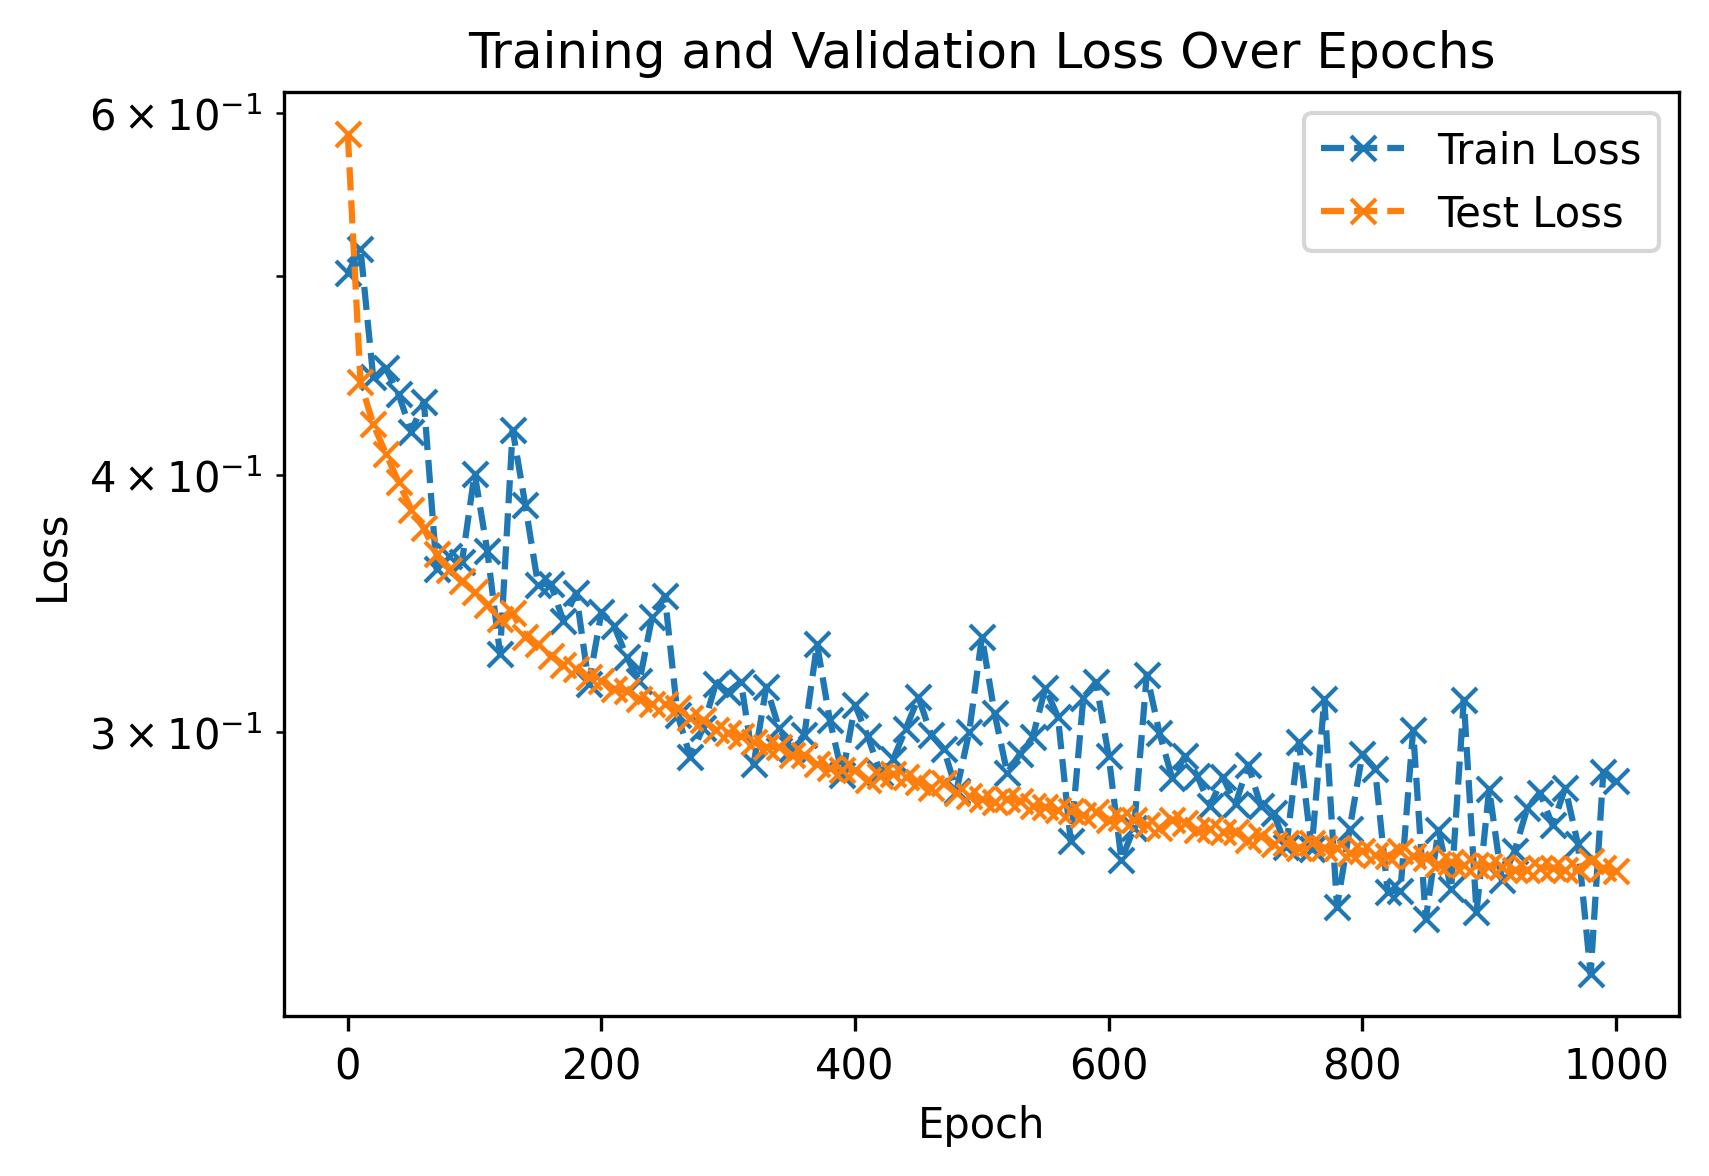

In [3]:

#output = io.load_train_test_data(train_dir, test_dir, image_filter="_img",
#                               mask_filter="_masks", look_one_level_down=False)
epoch = 1000
lrate = 0.01
wdecay = 0.0001

model = models.CellposeModel(model_type="cyto3", gpu=True)
io.logger_setup()

normalize_custom_training = {
    "lowhigh": [0,255],
    "percentile": None,
    "normalize": True,
    "norm3D": False,
    "sharpen_radius": 0,
    "smooth_radius": 0,
    "tile_norm_blocksize": 0,
    "tile_norm_smooth3D": 1,
    "invert": False
}



model_path = train.train_seg(model.net, 
                            train_files=images_train, train_labels_files=masks_train,
                            normalize=normalize_custom_training, channels=[1,0], compute_flows=False,
                            test_files=images_test, test_labels_files=masks_test,
                            weight_decay=wdecay, SGD=True, learning_rate=lrate,
                            n_epochs=epoch, 
                            save_path= model_path, model_name=modelName, batch_size=16)

import numpy as np

train_loss = model_path[1]
test_loss = model_path[2]
train_loss = train_loss[test_loss != 0]
test_loss = test_loss[test_loss != 0]
epochs = np.linspace(0, epoch, num=int(epoch/10)+1)

# Create a figure and a set of axes
fig = plt.figure(figsize=(6, 4))
# Plot the two curves on the same axes
#plt.plot(range(epoch), train_loss, label='Train Loss', linestyle='-', marker='o')
plt.plot(epochs, train_loss, label='Train Loss', linestyle='--', marker='x')
plt.plot(epochs, test_loss, label='Test Loss', linestyle='--', marker='x')
plt.yscale('log') 
# Add labels, title, and legend
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()

# Display the plot
plt.show()


# cellpose.train.train_seg(net, train_data=None, train_labels=None, train_files=None, train_labels_files=None, train_probs=None, test_data=None, test_labels=None,
#                           test_files=None, test_labels_files=None, test_probs=None, load_files=True, batch_size=8, learning_rate=0.005, n_epochs=2000,
#                          weight_decay=1e-05, momentum=0.9, SGD=False, channels=None, channel_axis=None, rgb=False, normalize=True, compute_flows=False,
#                            save_path=None, save_every=100, nimg_per_epoch=None, nimg_test_per_epoch=None, rescale=True, scale_range=None, 
#                          bsize=224, min_train_masks=5, model_name=None)

